In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [6]:
train_data = pd.read_csv(r"D:\Learn\pytorch\california-house-prices\train.csv")
test_data = pd.read_csv(r"D:\Learn\pytorch\california-house-prices\test.csv")

In [15]:
print(train_data.shape)
print(test_data.shape)

(47439, 41)
(31626, 40)


In [17]:
print(train_data.iloc[0:4, [0, 1, 2, 4, 5, 8, 9, 10, 11, 12, -8, -4, -3]])

   Id            Address  Sold Price          Type  Year built  \
0   0        540 Pine Ln   3825000.0  SingleFamily      1969.0   
1   1     1727 W 67th St    505000.0  SingleFamily      1926.0   
2   2     28093 Pine Ave    140000.0  SingleFamily      1958.0   
3   3  10750 Braddock Dr   1775000.0  SingleFamily      1947.0   

                                         Parking     Lot  \
0             Garage, Garage - Attached, Covered     1.0   
1                       Detached Carport, Garage  4047.0   
2                                       0 spaces  9147.0   
3  Detached Carport, Driveway, Garage - Two Door     NaN   

                                            Bedrooms  Bathrooms  \
0  Ground Floor Bedroom, Master Bedroom on Ground...        0.0   
1                                                  3        2.0   
2                                                  2        3.0   
3                                                  5        3.0   

   Full bathrooms  Annual tax am

In [44]:
train_features = train_data.drop(columns=['Id', 'Sold Price'])
test_features = test_data.drop(columns=['Id'])
train_soldprice = train_data['Sold Price'].copy()

In [45]:
train_features.columns.equals(test_features.columns)

True

In [42]:
#整合两个数据集 下一步做统一处理
all_features = pd.concat((train_features, test_features))

In [46]:
print(train_features.shape)
print(test_features.shape)
print(all_features.shape)

(47439, 39)
(31626, 39)
(79065, 39)


In [49]:
numeric_features = train_features.select_dtypes(
    include=['number']
).columns

print(numeric_features)
print(len(numeric_features))
print('Sold Price' in all_features.columns)
print('Id' in all_features.columns)

Index(['Year built', 'Lot', 'Bathrooms', 'Full bathrooms',
       'Total interior livable area', 'Total spaces', 'Garage spaces',
       'Elementary School Score', 'Elementary School Distance',
       'Middle School Score', 'Middle School Distance', 'High School Score',
       'High School Distance', 'Tax assessed value', 'Annual tax amount',
       'Listed Price', 'Last Sold Price', 'Zip'],
      dtype='object')
18
False
False


In [53]:
# 确认目标值没有混入特征
assert 'Sold Price' not in all_features.columns

# 记录训练集行数，用于区分训练部分和测试部分
n_train = len(train_data)

# 删除非数值字段，只保留数值特征
all_features = all_features.select_dtypes(include=['number']).copy()
numeric_features = all_features.columns

print('保留的数值特征数量:', len(numeric_features))
print('all_features 形状:', all_features.shape)

# 只用训练部分计算缺失值填充值
train_part = all_features.iloc[:n_train]
print('补缺前缺失值总数:', train_part.isna().sum().sum())

fill_values = train_part.median()
all_features[numeric_features] = all_features[numeric_features].fillna(fill_values)

print('补缺后缺失值总数:', all_features.isna().sum().sum())

# 只用训练部分计算标准化参数
train_part = all_features.iloc[:n_train]
feature_mean = train_part.mean()
feature_std = train_part.std().replace(0, 1)

# 使用训练部分的均值和标准差标准化全部数据
all_features = (all_features - feature_mean) / feature_std

print('标准化后形状:', all_features.shape)
print('训练部分标准化后的均值:')
print(all_features.iloc[:n_train].mean().round(4))

保留的数值特征数量: 18
all_features 形状: (79065, 18)
补缺前缺失值总数: 0
补缺后缺失值总数: 0
标准化后形状: (79065, 18)
训练部分标准化后的均值:
Year built                     0.0
Lot                            0.0
Bathrooms                      0.0
Full bathrooms                -0.0
Total interior livable area    0.0
Total spaces                   0.0
Garage spaces                  0.0
Elementary School Score       -0.0
Elementary School Distance     0.0
Middle School Score            0.0
Middle School Distance        -0.0
High School Score              0.0
High School Distance           0.0
Tax assessed value            -0.0
Annual tax amount              0.0
Listed Price                   0.0
Last Sold Price                0.0
Zip                            0.0
dtype: float64


In [54]:
print(all_features.iloc[0:4])

   Year built       Lot  Bathrooms  Full bathrooms  \
0    0.084169 -0.016718  -2.028796       -0.089963   
1   -0.214037 -0.016312  -0.287090       -0.089963   
2    0.007884 -0.015802   0.583763       -1.225611   
3   -0.068402 -0.016067   0.583763        1.045685   

   Total interior livable area  Total spaces  Garage spaces  \
0                    -0.006851     -0.174370      -0.166966   
1                    -0.005776     -0.062319      -0.054322   
2                    -0.005430     -0.174370      -0.166966   
3                    -0.003628     -0.174370      -0.166966   

   Elementary School Score  Elementary School Distance  Middle School Score  \
0                 0.627169                   -0.309358            -0.126924   
1                -1.379188                   -0.129288            -1.979779   
2                 0.125580                   -0.264341            -0.126924   
3                 1.630348                   -0.399393             1.108312   

   Middle School 

In [55]:
all_features.shape

(79065, 18)

In [59]:
n_train = train_data.shape[0]

train_features = torch.tensor(
    all_features.iloc[:n_train].values,
    dtype=torch.float32
)

test_features = torch.tensor(
    all_features.iloc[n_train:].values,
    dtype=torch.float32
)

train_labels = torch.tensor(
    train_data['Sold Price'].values.reshape(-1, 1),
    dtype=torch.float32
)

In [64]:
#-------------------------------------------
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net

In [65]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

In [66]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 这里使用的是Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [67]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

In [68]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

折1，训练log rmse8.044678, 验证log rmse8.110597
折2，训练log rmse7.931189, 验证log rmse7.589715
折3，训练log rmse7.915749, 验证log rmse7.772366
折4，训练log rmse8.013059, 验证log rmse8.035261
折5，训练log rmse7.908445, 验证log rmse8.371870
5-折验证: 平均训练log rmse: 7.962624, 平均验证log rmse: 7.975962


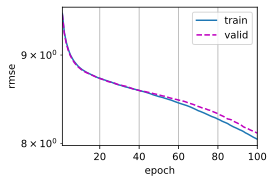

In [69]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')